# PyTorch Tensor Basics

A ground-up crash course on PyTorch tensors: how they're created, how they live in memory,
how to reshape and manipulate them, and how automatic differentiation works.

**Prerequisites:** Familiarity with linear algebra, MATLAB, and Python/NumPy.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.12.0


## 1. The Core Object: `torch.Tensor`

A tensor is an n-dimensional array of numbers — like a MATLAB matrix or NumPy ndarray.
Under the hood, every tensor has:
- A flat **storage** (1D block of memory)
- **Shape** — the dimensions
- **Strides** — how many elements to skip in storage to move one step along each dimension
- **dtype** — data type (float32, int64, etc.)
- **device** — cpu or cuda

We'll inspect all of these to build intuition for what's really happening in memory.

In [2]:
# Create a 3x4 tensor from a range
X = torch.arange(12).reshape(3, 4)
print("X:")
print(X)
print(f"\nShape: {X.shape}")
print(f"Strides: {X.stride()}")
print(f"dtype: {X.dtype}")
print(f"device: {X.device}")
print(f"\nUnderlying storage (flat memory):")
print(list(X.storage()))
print(f"\nIs contiguous: {X.is_contiguous()}")
print("\n--- Interpretation ---")
print("Stride (4, 1) means: skip 4 elements to move down a row, skip 1 to move right a column.")
print("The storage is just the numbers 0-11 laid out flat. Shape + strides = the 2D view.")

X:
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])

Shape: torch.Size([3, 4])
Strides: (4, 1)
dtype: torch.int64
device: cpu

Underlying storage (flat memory):
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

Is contiguous: True

--- Interpretation ---
Stride (4, 1) means: skip 4 elements to move down a row, skip 1 to move right a column.
The storage is just the numbers 0-11 laid out flat. Shape + strides = the 2D view.


/var/folders/kw/fl642xjn4yq6w0kq6gtss8d40000gr/T/ipykernel_4611/2289709843.py:10: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  print(list(X.storage()))


## 2. Storage and Strides — Transpose Without Copying

When you transpose a tensor, PyTorch does NOT copy the data.
It just swaps the strides. The storage stays identical.
This makes transpose essentially free — but the tensor becomes 'non-contiguous'
because elements are no longer sequential in memory for the new shape.

We'll see:
- Same storage pointer before and after transpose
- Strides swap
- `is_contiguous()` becomes False
- `.view()` fails on non-contiguous tensors

In [3]:
X = torch.arange(12).reshape(3, 4)
Y = X.T  # transpose

print("X (original):")
print(X)
print(f"  Shape: {X.shape}, Strides: {X.stride()}, Contiguous: {X.is_contiguous()}")

print(f"\nY (transposed):")
print(Y)
print(f"  Shape: {Y.shape}, Strides: {Y.stride()}, Contiguous: {Y.is_contiguous()}")

print(f"\nSame storage? {X.data_ptr() == Y.data_ptr()}")
print("The data_ptr is the memory address. They're identical — no copy happened.")

print(f"\nX storage: {list(X.storage())}")
print(f"Y storage: {list(Y.storage())}")
print("Identical! Transpose only changed the strides, not the data.")

X (original):
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
  Shape: torch.Size([3, 4]), Strides: (4, 1), Contiguous: True

Y (transposed):
tensor([[ 0,  4,  8],
        [ 1,  5,  9],
        [ 2,  6, 10],
        [ 3,  7, 11]])
  Shape: torch.Size([4, 3]), Strides: (1, 4), Contiguous: False

Same storage? True
The data_ptr is the memory address. They're identical — no copy happened.

X storage: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Y storage: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Identical! Transpose only changed the strides, not the data.


In [4]:
# .view() requires contiguous memory — it refuses to silently copy
print("Attempting Y.view(12) on non-contiguous tensor...")
try:
    Y.view(12)
except RuntimeError as e:
    print(f"ERROR: {e}")

print("\nFix: call .contiguous() first (this DOES copy to a new sequential layout)")
Z = Y.contiguous()
print(f"Z = Y.contiguous()")
print(f"  Z.is_contiguous(): {Z.is_contiguous()}")
print(f"  Same storage as Y? {Z.data_ptr() == Y.data_ptr()}")
print(f"  Z.view(12): {Z.view(12)}")
print("\n.reshape() is the lenient version — it calls .contiguous() for you if needed.")

Attempting Y.view(12) on non-contiguous tensor...
ERROR: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.

Fix: call .contiguous() first (this DOES copy to a new sequential layout)
Z = Y.contiguous()
  Z.is_contiguous(): True
  Same storage as Y? False
  Z.view(12): tensor([ 0,  4,  8,  1,  5,  9,  2,  6, 10,  3,  7, 11])

.reshape() is the lenient version — it calls .contiguous() for you if needed.


## 3. Creating Tensors

Multiple ways to create tensors — from literals, from allocation functions,
and from NumPy arrays (shared memory, no copy).

We'll see the most common constructors and verify the NumPy shared-memory behavior.

In [5]:
# From data
a = torch.tensor([1.0, 2.0, 3.0])
print(f"From list: {a}, dtype: {a.dtype}")

# Allocation functions
print(f"\nzeros(2,3):\n{torch.zeros(2, 3)}")
print(f"\nones(2,3):\n{torch.ones(2, 3)}")
print(f"\nrandn(2,3) (normal dist):\n{torch.randn(2, 3)}")
print(f"\narange(0, 10, 2): {torch.arange(0, 10, 2)}")
print(f"\nlinspace(0, 1, 5): {torch.linspace(0, 1, 5)}")

# From NumPy — SHARED MEMORY
n = np.array([10.0, 20.0, 30.0])
t = torch.from_numpy(n)
print(f"\nNumPy array: {n}")
print(f"Torch tensor from numpy: {t}")
t[0] = 999.0
print(f"After mutating tensor[0] = 999:")
print(f"  Tensor: {t}")
print(f"  NumPy:  {n}")
print("They share memory! Mutating one mutates the other.")

From list: tensor([1., 2., 3.]), dtype: torch.float32

zeros(2,3):
tensor([[0., 0., 0.],
        [0., 0., 0.]])

ones(2,3):
tensor([[1., 1., 1.],
        [1., 1., 1.]])

randn(2,3) (normal dist):
tensor([[ 0.1735,  0.4263, -1.3075],
        [ 0.0209,  0.8117,  0.4649]])

arange(0, 10, 2): tensor([0, 2, 4, 6, 8])

linspace(0, 1, 5): tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])

NumPy array: [10. 20. 30.]
Torch tensor from numpy: tensor([10., 20., 30.], dtype=torch.float64)
After mutating tensor[0] = 999:
  Tensor: tensor([999.,  20.,  30.], dtype=torch.float64)
  NumPy:  [999.  20.  30.]
They share memory! Mutating one mutates the other.


## 4. Reshaping & Dimension Manipulation

These operations reinterpret the same flat storage with different shapes/strides.
Key functions:
- `.view()` — new shape, same memory (fails if non-contiguous)
- `.reshape()` — new shape, copies if needed
- `.transpose()` / `.permute()` — swap dimensions (no copy)
- `.unsqueeze()` / `.squeeze()` — add/remove size-1 dims
- `.expand()` — broadcast without copying (stride-0 trick)

We'll see how each one affects shape, strides, and memory.

In [6]:
X = torch.arange(24).reshape(2, 3, 4)
print(f"X shape: {X.shape}, strides: {X.stride()}")
print("Stride (12, 4, 1): skip 12 for dim0, 4 for dim1, 1 for dim2\n")

# View — reinterpret as different shape
V = X.view(6, 4)
print(f"X.view(6, 4) shape: {V.shape}, same memory: {V.data_ptr() == X.data_ptr()}")

# Flatten
F = X.view(-1)
print(f"X.view(-1) shape: {F.shape} (flatten, -1 infers the size)")

# Permute — arbitrary dimension reorder
P = X.permute(2, 0, 1)
print(f"\nX.permute(2,0,1) shape: {P.shape}, strides: {P.stride()}")
print(f"  Contiguous: {P.is_contiguous()}, same memory: {P.data_ptr() == X.data_ptr()}")

# Unsqueeze — add a size-1 dimension
a = torch.randn(5)
print(f"\na shape: {a.shape}")
print(f"a.unsqueeze(0) shape: {a.unsqueeze(0).shape}  (row vector)")
print(f"a.unsqueeze(1) shape: {a.unsqueeze(1).shape}  (column vector)")

# Expand — broadcast without copying
row = torch.tensor([[1, 2, 3, 4]])
print(f"\nrow shape: {row.shape}")
expanded = row.expand(3, 4)
print(f"row.expand(3, 4) shape: {expanded.shape}, strides: {expanded.stride()}")
print("Stride (0, 1): the 0 means dim0 doesn't advance in memory — it repeats the same row!")

X shape: torch.Size([2, 3, 4]), strides: (12, 4, 1)
Stride (12, 4, 1): skip 12 for dim0, 4 for dim1, 1 for dim2

X.view(6, 4) shape: torch.Size([6, 4]), same memory: True
X.view(-1) shape: torch.Size([24]) (flatten, -1 infers the size)

X.permute(2,0,1) shape: torch.Size([4, 2, 3]), strides: (1, 12, 4)
  Contiguous: False, same memory: True

a shape: torch.Size([5])
a.unsqueeze(0) shape: torch.Size([1, 5])  (row vector)
a.unsqueeze(1) shape: torch.Size([5, 1])  (column vector)

row shape: torch.Size([1, 4])
row.expand(3, 4) shape: torch.Size([3, 4]), strides: (0, 1)
Stride (0, 1): the 0 means dim0 doesn't advance in memory — it repeats the same row!


### Why is it 'same memory' but 'not contiguous'?

This is the key mental model. Imagine the storage as a row of mailboxes numbered 0-11.
The original 3x4 matrix reads them left-to-right, row by row: 0,1,2,3 | 4,5,6,7 | 8,9,10,11.
That's contiguous — sequential access.

After transpose, the 4x3 matrix needs to read: 0,4,8 | 1,5,9 | 2,6,10 | 3,7,11.
It's jumping around in the **same mailboxes** — same memory, but the access pattern is no longer sequential.
That's non-contiguous.

Think of it like a book: the pages (storage) haven't moved. But instead of reading page 1,2,3,4...
you're now reading page 1,4,7,2,5,8,3,6,9... The book is the same. Your reading order changed.

`.view()` needs sequential access because it just assigns new strides to the existing flat sequence.
If elements aren't in order, no stride tuple can map the new shape onto the existing layout.
`.contiguous()` fixes this by copying elements into a fresh block in the new sequential order.

In [7]:
# Visual demonstration: same memory, different access patterns
X = torch.arange(12).reshape(3, 4)
Y = X.T

print("Storage (flat memory): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]")
print()
print("X reads it as 3x4 (row-major, sequential):")
for row in range(3):
    indices = [row * X.stride()[0] + col * X.stride()[1] for col in range(4)]
    values = [int(X[row, col]) for col in range(4)]
    print(f"  Row {row}: storage positions {indices} -> values {values}")

print()
print("Y (transpose) reads SAME storage as 4x3 (jumping around):")
for row in range(4):
    indices = [row * Y.stride()[0] + col * Y.stride()[1] for col in range(3)]
    values = [int(Y[row, col]) for col in range(3)]
    print(f"  Row {row}: storage positions {indices} -> values {values}")

print()
print("X access order: 0,1,2,3,4,5,6,7,8,9,10,11 (sequential = contiguous)")
print("Y access order: 0,4,8,1,5,9,2,6,10,3,7,11 (jumping = NOT contiguous)")
print("\nSame data. Same memory address. Different traversal order.")
print(f"Proof — same pointer: {X.data_ptr() == Y.data_ptr()}")

Storage (flat memory): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

X reads it as 3x4 (row-major, sequential):
  Row 0: storage positions [0, 1, 2, 3] -> values [0, 1, 2, 3]
  Row 1: storage positions [4, 5, 6, 7] -> values [4, 5, 6, 7]
  Row 2: storage positions [8, 9, 10, 11] -> values [8, 9, 10, 11]

Y (transpose) reads SAME storage as 4x3 (jumping around):
  Row 0: storage positions [0, 4, 8] -> values [0, 4, 8]
  Row 1: storage positions [1, 5, 9] -> values [1, 5, 9]
  Row 2: storage positions [2, 6, 10] -> values [2, 6, 10]
  Row 3: storage positions [3, 7, 11] -> values [3, 7, 11]

X access order: 0,1,2,3,4,5,6,7,8,9,10,11 (sequential = contiguous)
Y access order: 0,4,8,1,5,9,2,6,10,3,7,11 (jumping = NOT contiguous)

Same data. Same memory address. Different traversal order.
Proof — same pointer: True


## 5. Indexing

Very similar to NumPy. Supports slicing, boolean masks, and advanced (fancy) indexing.
We'll see each style and how they return views vs copies.

In [8]:
X = torch.arange(20).reshape(4, 5)
print("X:")
print(X)

print(f"\nX[0] (first row): {X[0]}")
print(f"X[:, 0] (first col): {X[:, 0]}")
print(f"X[1:3, 2:4] (slice):\n{X[1:3, 2:4]}")

# Boolean mask
mask = X > 10
print(f"\nX[X > 10] (boolean mask): {X[mask]}")

# Advanced indexing
idx = torch.tensor([0, 2, 3])
print(f"\nX[idx] (rows 0, 2, 3):\n{X[idx]}")

X:
tensor([[ 0,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14],
        [15, 16, 17, 18, 19]])

X[0] (first row): tensor([0, 1, 2, 3, 4])
X[:, 0] (first col): tensor([ 0,  5, 10, 15])
X[1:3, 2:4] (slice):
tensor([[ 7,  8],
        [12, 13]])

X[X > 10] (boolean mask): tensor([11, 12, 13, 14, 15, 16, 17, 18, 19])

X[idx] (rows 0, 2, 3):
tensor([[ 0,  1,  2,  3,  4],
        [10, 11, 12, 13, 14],
        [15, 16, 17, 18, 19]])


## 6. Key Operations

Element-wise ops, matrix multiplication, einsum, and reductions.
The critical distinction: `*` is element-wise (like MATLAB `.*`), `@` is matmul (like MATLAB `*`).

We'll also see `torch.einsum` — a powerful notation for expressing any linear algebra operation
by labeling dimensions explicitly.

In [9]:
A = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
B = torch.tensor([[5.0, 6.0], [7.0, 8.0]])

print("A:"); print(A)
print("B:"); print(B)

print(f"\nA + B (element-wise add):\n{A + B}")
print(f"\nA * B (element-wise multiply, like MATLAB .*):\n{A * B}")
print(f"\nA @ B (matrix multiply, like MATLAB A*B):\n{A @ B}")

# Einsum — explicit dimension labeling
C = torch.einsum('ij,jk->ik', A, B)
print(f"\neinsum('ij,jk->ik', A, B) (matmul via einsum):\n{C}")

# Batched matmul
batch_A = torch.randn(4, 3, 2)  # 4 matrices of 3x2
batch_B = torch.randn(4, 2, 5)  # 4 matrices of 2x5
batch_C = torch.bmm(batch_A, batch_B)
print(f"\nBatched matmul: {batch_A.shape} @ {batch_B.shape} = {batch_C.shape}")
print("bmm multiplies each pair of 2D matrices independently across the batch dim.")

# Reductions
X = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
print(f"\nX:\n{X}")
print(f"X.sum(dim=0) (sum down rows): {X.sum(dim=0)}")
print(f"X.sum(dim=1) (sum across cols): {X.sum(dim=1)}")
print(f"X.mean(): {X.mean()}")
vals, idxs = X.max(dim=1)
print(f"X.max(dim=1): values={vals}, indices={idxs}")

A:
tensor([[1., 2.],
        [3., 4.]])
B:
tensor([[5., 6.],
        [7., 8.]])

A + B (element-wise add):
tensor([[ 6.,  8.],
        [10., 12.]])

A * B (element-wise multiply, like MATLAB .*):
tensor([[ 5., 12.],
        [21., 32.]])

A @ B (matrix multiply, like MATLAB A*B):
tensor([[19., 22.],
        [43., 50.]])

einsum('ij,jk->ik', A, B) (matmul via einsum):
tensor([[19., 22.],
        [43., 50.]])

Batched matmul: torch.Size([4, 3, 2]) @ torch.Size([4, 2, 5]) = torch.Size([4, 3, 5])
bmm multiplies each pair of 2D matrices independently across the batch dim.

X:
tensor([[1., 2., 3.],
        [4., 5., 6.]])
X.sum(dim=0) (sum down rows): tensor([5., 7., 9.])
X.sum(dim=1) (sum across cols): tensor([ 6., 15.])
X.mean(): 3.5
X.max(dim=1): values=tensor([3., 6.]), indices=tensor([2, 2])


### Understanding `einsum` notation

Einstein summation (`einsum`) lets you express any tensor operation by labeling each dimension
with a letter. The rules:

1. Each input tensor gets a string of letters — one per dimension. `'ij'` means a 2D tensor with rows=i, cols=j.
2. The `->` arrow specifies which dimensions appear in the output.
3. Any letter that appears in the inputs but NOT in the output gets **summed over** (contracted).
4. Repeated letters between inputs mean those dimensions are aligned (like the shared dimension in matmul).

Examples:
- `'ij,jk->ik'` = matrix multiply. `j` is shared and summed over. Result has dims i,k.
- `'ij->j'` = sum over rows (i disappears). Same as `.sum(dim=0)`.
- `'ii->'` = trace (sum of diagonal). Both dims are `i`, so we walk the diagonal and sum.
- `'bij,bjk->bik'` = batched matmul. `b` is the batch dim (preserved), `j` is contracted.

Think of it as: **label your dimensions, say which ones survive in the output, and PyTorch figures out the rest.**

In [10]:
A = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
B = torch.tensor([[5.0, 6.0], [7.0, 8.0]])

# Matrix multiply: 'ij,jk->ik'
# A is (i=2, j=2), B is (j=2, k=2). j is shared and summed. Output is (i=2, k=2).
print("Matrix multiply: einsum('ij,jk->ik', A, B)")
print(torch.einsum('ij,jk->ik', A, B))

# Trace: 'ii->'
# Walk the diagonal (where row index = col index), sum everything.
print(f"\nTrace: einsum('ii->', A) = {torch.einsum('ii->', A)}")
print(f"  (That's 1+4 = {A[0,0] + A[1,1]})")

# Outer product: 'i,j->ij'
# No shared dims, no contraction. Every combo of i,j appears in output.
v1 = torch.tensor([1.0, 2.0, 3.0])
v2 = torch.tensor([4.0, 5.0])
print(f"\nOuter product: einsum('i,j->ij', v1, v2)")
print(torch.einsum('i,j->ij', v1, v2))

# Batched dot product (used in attention): 'bij,bkj->bik'
# b=batch, i=query positions, k=key positions, j=head_dim (contracted)
Q = torch.randn(2, 3, 4)  # (batch=2, seq=3, dim=4)
K = torch.randn(2, 3, 4)  # (batch=2, seq=3, dim=4)
scores = torch.einsum('bij,bkj->bik', Q, K)
print(f"\nBatched dot product: Q{list(Q.shape)} x K{list(K.shape)} -> scores{list(scores.shape)}")
print("b is batch (preserved), j is head_dim (summed), i and k are sequence positions.")

Matrix multiply: einsum('ij,jk->ik', A, B)
tensor([[19., 22.],
        [43., 50.]])

Trace: einsum('ii->', A) = 5.0
  (That's 1+4 = 5.0)

Outer product: einsum('i,j->ij', v1, v2)
tensor([[ 4.,  5.],
        [ 8., 10.],
        [12., 15.]])

Batched dot product: Q[2, 3, 4] x K[2, 3, 4] -> scores[2, 3, 3]
b is batch (preserved), j is head_dim (summed), i and k are sequence positions.


### `bmm` vs `matmul` vs `@` — which to use for higher dimensions

- **`torch.bmm(A, B)`** — ONLY works on exactly 3D tensors. Shape must be `(batch, n, m)` @ `(batch, m, p)`.
  It's explicit and strict: one batch dimension, two matrix dimensions. Nothing else.

- **`torch.matmul(A, B)` or `A @ B`** — works on ANY number of dimensions:
  - 1D x 1D = dot product (scalar)
  - 2D x 2D = matrix multiply
  - 3D+ x 3D+ = the last two dims are the matrix, all leading dims are batch (with broadcasting)

- **`torch.einsum`** — works on anything, you label the dims yourself.

For 4D+ tensors (like attention with shape `(batch, heads, seq, dim)`), use `@` or `einsum`.
`bmm` won't work because it demands exactly 3 dimensions.

In [11]:
# 4D matmul — like multi-head attention
# Shape: (batch, heads, seq_len, head_dim)
Q = torch.randn(2, 8, 10, 64)  # 2 batches, 8 heads, 10 tokens, 64-dim
K = torch.randn(2, 8, 10, 64)

# Attention scores: Q @ K^T -> (batch, heads, seq, seq)
scores = Q @ K.transpose(-1, -2)  # transpose last two dims only
print(f"Q shape: {Q.shape}")
print(f"K shape: {K.shape}")
print(f"K transposed shape: {K.transpose(-1, -2).shape}")
print(f"Q @ K^T shape: {scores.shape}")
print("\nThe @ operator treats dims 0,1 as batch and multiplies the last two dims.")
print("This is 2*8=16 independent 10x64 @ 64x10 matrix multiplies.")

# bmm would require flattening batch+heads first:
Q_flat = Q.reshape(16, 10, 64)  # merge batch and heads
K_flat = K.reshape(16, 10, 64)
scores_bmm = torch.bmm(Q_flat, K_flat.transpose(1, 2))
print(f"\nbmm approach: reshape to {Q_flat.shape}, then bmm -> {scores_bmm.shape}")
print("Same result, but @ handles the 4D case directly without reshaping.")

# Broadcasting: a shared weight matrix applied to all batches
W = torch.randn(64, 32)  # 2D weight matrix
X = torch.randn(2, 8, 10, 64)  # 4D input
out = X @ W  # W broadcasts across batch and heads
print(f"\nBroadcast matmul: {list(X.shape)} @ {list(W.shape)} -> {list(out.shape)}")
print("W is shared across all batches and heads — no copy, just broadcasting.")

Q shape: torch.Size([2, 8, 10, 64])
K shape: torch.Size([2, 8, 10, 64])
K transposed shape: torch.Size([2, 8, 64, 10])
Q @ K^T shape: torch.Size([2, 8, 10, 10])

The @ operator treats dims 0,1 as batch and multiplies the last two dims.
This is 2*8=16 independent 10x64 @ 64x10 matrix multiplies.

bmm approach: reshape to torch.Size([16, 10, 64]), then bmm -> torch.Size([16, 10, 10])
Same result, but @ handles the 4D case directly without reshaping.

Broadcast matmul: [2, 8, 10, 64] @ [64, 32] -> [2, 8, 10, 32]
W is shared across all batches and heads — no copy, just broadcasting.


## 7. Broadcasting

Same rules as NumPy (and MATLAB's implicit expansion since R2016b):
- Dimensions compared right-to-left
- Size-1 dimensions stretch to match
- Missing dimensions treated as size 1

We'll see broadcasting in action and verify no extra memory is allocated.

In [12]:
A = torch.arange(12).reshape(3, 4).float()
b = torch.tensor([100.0, 200.0, 300.0, 400.0])  # shape (4,)

print(f"A shape: {A.shape}")
print(f"b shape: {b.shape}")
print(f"\nA + b (b broadcasts across rows):")
print(A + b)

# Column broadcast
c = torch.tensor([[10.0], [20.0], [30.0]])  # shape (3, 1)
print(f"\nc shape: {c.shape}")
print(f"A + c (c broadcasts across columns):")
print(A + c)

print("\n--- Rule ---")
print("No data is copied during broadcasting. PyTorch uses stride=0 internally.")

A shape: torch.Size([3, 4])
b shape: torch.Size([4])

A + b (b broadcasts across rows):
tensor([[100., 201., 302., 403.],
        [104., 205., 306., 407.],
        [108., 209., 310., 411.]])

c shape: torch.Size([3, 1])
A + c (c broadcasts across columns):
tensor([[10., 11., 12., 13.],
        [24., 25., 26., 27.],
        [38., 39., 40., 41.]])

--- Rule ---
No data is copied during broadcasting. PyTorch uses stride=0 internally.


## 8. Autograd — The Gradient Engine

This is what makes PyTorch more than NumPy. When `requires_grad=True`,
every operation is recorded in a computational graph. Call `.backward()`
and gradients flow back through the graph via chain rule.

We'll see:
- How the graph is built (`.grad_fn` on each tensor)
- How `.backward()` populates `.grad`
- How `torch.no_grad()` and `.detach()` break the graph

In [13]:
# Create a 'parameter' — a tensor that tracks gradients
W = torch.tensor([[1.0, 2.0], [3.0, 4.0]], requires_grad=True)
x = torch.tensor([1.0, 1.0])

print(f"W requires_grad: {W.requires_grad}")
print(f"x requires_grad: {x.requires_grad}")

# Forward pass — builds the computational graph
y = W @ x          # matrix-vector multiply
loss = y.sum()     # scalar output

print(f"\ny = W @ x = {y}")
print(f"loss = y.sum() = {loss}")
print(f"loss.grad_fn: {loss.grad_fn}")
print(f"y.grad_fn: {y.grad_fn}")
print("Each tensor remembers what created it — that's the graph.")

# Backward pass — compute gradients
loss.backward()
print(f"\nW.grad (d(loss)/dW):\n{W.grad}")
print("Each element of W.grad tells you: if I nudge this weight, how does the loss change?")

# IMPORTANT: gradients accumulate!
print(f"\nBefore zeroing, W.grad:\n{W.grad}")
W.grad.zero_()
print(f"After W.grad.zero_():\n{W.grad}")

W requires_grad: True
x requires_grad: False

y = W @ x = tensor([3., 7.], grad_fn=<MvBackward0>)
loss = y.sum() = 10.0
loss.grad_fn: <SumBackward0 object at 0x1085f5fc0>
y.grad_fn: <MvBackward0 object at 0x1085f5fc0>
Each tensor remembers what created it — that's the graph.

W.grad (d(loss)/dW):
tensor([[1., 1.],
        [1., 1.]])
Each element of W.grad tells you: if I nudge this weight, how does the loss change?

Before zeroing, W.grad:
tensor([[1., 1.],
        [1., 1.]])
After W.grad.zero_():
tensor([[0., 0.],
        [0., 0.]])


In [14]:
# Disabling gradient tracking
W = torch.tensor([[1.0, 2.0], [3.0, 4.0]], requires_grad=True)
x = torch.tensor([1.0, 1.0])

# with torch.no_grad() — nothing is recorded
with torch.no_grad():
    y_no_track = W @ x
print(f"Inside no_grad: y.requires_grad = {y_no_track.requires_grad}")
print(f"  y.grad_fn = {y_no_track.grad_fn}  (None — no graph)")

# .detach() — returns a view disconnected from the graph
y_tracked = W @ x
y_detached = y_tracked.detach()
print(f"\ny_tracked.grad_fn: {y_tracked.grad_fn}")
print(f"y_detached.grad_fn: {y_detached.grad_fn}  (None — detached)")
print(f"Same data? {y_detached.data_ptr() == y_tracked.data_ptr()}")
print("\n.detach() is how you 'freeze' a tensor — use it for target networks, stop-gradient, etc.")

Inside no_grad: y.requires_grad = False
  y.grad_fn = None  (None — no graph)

y_tracked.grad_fn: <MvBackward0 object at 0x11409a320>
y_detached.grad_fn: None  (None — detached)
Same data? True

.detach() is how you 'freeze' a tensor — use it for target networks, stop-gradient, etc.


### Multiple Loss Functions and Backpropagation

Yes — you can absolutely have multiple losses computed from the same network and backpropagate
through all of them. This is common in practice:

- **Multi-task learning**: one network predicts multiple things (e.g., object class + bounding box)
- **Regularization**: main loss + a penalty term (L2 weight decay, KL divergence, etc.)
- **GANs**: generator loss and discriminator loss share some parameters
- **Auxiliary losses**: intermediate layers get their own loss to improve gradient flow

The simplest approach: add the losses together into one scalar and call `.backward()` once.
The gradients from each loss accumulate in `.grad` (because gradients are additive by the chain rule).

You can also call `.backward()` multiple times on separate losses — gradients accumulate.
Just remember to zero gradients before the next optimization step.

In [15]:
# Multi-task example: one network, two losses
W = torch.randn(4, 3, requires_grad=True)  # shared weights
x = torch.randn(3)

# Forward pass produces one output
y = W @ x

# Two different losses computed from the same output
target_a = torch.tensor([1.0, 0.0, 0.0, 0.0])
target_b = torch.tensor([0.0, 0.0, 0.0, 1.0])

loss_a = ((y - target_a) ** 2).sum()  # MSE toward target A
loss_b = ((y - target_b) ** 2).sum()  # MSE toward target B

# Approach 1: combine losses, single backward
total_loss = loss_a + 0.5 * loss_b  # weighted combination
total_loss.backward()

print("Approach 1: Combined loss")
print(f"  loss_a = {loss_a.item():.4f}")
print(f"  loss_b = {loss_b.item():.4f}")
print(f"  total_loss = loss_a + 0.5*loss_b = {total_loss.item():.4f}")
print(f"  W.grad (from combined backward):\n{W.grad}")

# Approach 2: separate backwards (gradients accumulate)
W2 = torch.randn(4, 3, requires_grad=True)
y2 = W2 @ x
loss_a2 = ((y2 - target_a) ** 2).sum()
loss_b2 = ((y2 - target_b) ** 2).sum()

loss_a2.backward(retain_graph=True)  # keep graph for second backward
print(f"\nApproach 2: Separate backwards")
print(f"  W2.grad after loss_a backward:\n{W2.grad}")

loss_b2.backward()  # gradients ACCUMULATE on top of previous
print(f"  W2.grad after BOTH backwards (accumulated):\n{W2.grad}")
print("\nNote: retain_graph=True is needed for the first backward because")
print("by default, backward() destroys the graph. The second loss still needs it.")
print("\nWhen would you want multiple losses?")
print("- Multi-task: predict class + bounding box from same features")
print("- Regularization: task loss + weight penalty")
print("- VAEs: reconstruction loss + KL divergence")
print("- RL: policy loss + value loss + entropy bonus")

Approach 1: Combined loss
  loss_a = 45.3050
  loss_b = 53.0614
  total_loss = loss_a + 0.5*loss_b = 71.8357
  W.grad (from combined backward):
tensor([[ -3.7452,   1.6366,  -6.8234],
        [-14.1427,   6.1804, -25.7669],
        [ 18.1412,  -7.9277,  33.0517],
        [  9.1377,  -3.9932,  16.6481]])

Approach 2: Separate backwards
  W2.grad after loss_a backward:
tensor([[ -3.2046,   1.4004,  -5.8385],
        [ -6.4575,   2.8219, -11.7650],
        [  4.1846,  -1.8287,   7.6239],
        [  1.3649,  -0.5965,   2.4867]])
  W2.grad after BOTH backwards (accumulated):
tensor([[ -8.8320,   3.8596, -16.0911],
        [-12.9150,   5.6439, -23.5301],
        [  8.3691,  -3.6573,  15.2479],
        [  5.1526,  -2.2517,   9.3876]])

Note: retain_graph=True is needed for the first backward because
by default, backward() destroys the graph. The second loss still needs it.

When would you want multiple losses?
- Multi-task: predict class + bounding box from same features
- Regularization: tas

## 9. Complex-Valued Tensors & Sinewaves

PyTorch natively supports complex numbers (`torch.cfloat`, `torch.cdouble`).
This is useful for signal processing, Fourier transforms, and wave-based models.

We'll:
- Create complex tensors from real and imaginary parts
- Generate a sinewave as a real tensor and as a complex phasor
- Plot both to see the waveform
- Demonstrate that standard operations (FFT, abs, angle) work on complex tensors

In [16]:
# Creating complex tensors
real = torch.tensor([1.0, 2.0, 3.0])
imag = torch.tensor([4.0, 5.0, 6.0])
z = torch.complex(real, imag)

print(f"Real part: {real}")
print(f"Imag part: {imag}")
print(f"Complex tensor z: {z}")
print(f"dtype: {z.dtype}")
print(f"z.real: {z.real}")
print(f"z.imag: {z.imag}")
print(f"z.abs() (magnitude): {z.abs()}")
print(f"z.angle() (phase in radians): {z.angle()}")

Real part: tensor([1., 2., 3.])
Imag part: tensor([4., 5., 6.])
Complex tensor z: tensor([1.+4.j, 2.+5.j, 3.+6.j])
dtype: torch.complex64
z.real: tensor([1., 2., 3.])
z.imag: tensor([4., 5., 6.])
z.abs() (magnitude): tensor([4.1231, 5.3852, 6.7082])
z.angle() (phase in radians): tensor([1.3258, 1.1903, 1.1071])


In [17]:
# Generate a sinewave
sample_rate = 1000  # Hz
duration = 0.05     # seconds (50ms — a few cycles)
freq = 100.0        # Hz

t = torch.linspace(0, duration, int(sample_rate * duration))
sinewave = torch.sin(2 * torch.pi * freq * t)

print(f"Time vector shape: {t.shape}")
print(f"Sinewave shape: {sinewave.shape}")
print(f"First 10 samples: {sinewave[:10]}")
print(f"\nThis is a {freq}Hz sine sampled at {sample_rate}Hz for {duration*1000:.0f}ms.")

Time vector shape: torch.Size([50])
Sinewave shape: torch.Size([50])
First 10 samples: tensor([ 0.0000,  0.5981,  0.9587,  0.9385,  0.5455, -0.0641, -0.6482, -0.9749,
        -0.9144, -0.4907])

This is a 100.0Hz sine sampled at 1000Hz for 50ms.


In [18]:
# Complex phasor: e^(j*2*pi*f*t) = cos(2*pi*f*t) + j*sin(2*pi*f*t)
phasor = torch.exp(1j * 2 * torch.pi * freq * t.to(torch.cfloat))

print(f"Phasor dtype: {phasor.dtype}")
print(f"Phasor shape: {phasor.shape}")
print(f"Real part is cosine, imag part is sine.")
print(f"phasor.real[:5]: {phasor.real[:5]}")
print(f"phasor.imag[:5]: {phasor.imag[:5]}")
print(f"sinewave[:5]:    {sinewave[:5]}")
print("\nThe imaginary part of the phasor matches our sinewave.")

Phasor dtype: torch.complex64
Phasor shape: torch.Size([50])
Real part is cosine, imag part is sine.
phasor.real[:5]: tensor([ 1.0000,  0.8014,  0.2845, -0.3454, -0.8381])
phasor.imag[:5]: tensor([0.0000, 0.5981, 0.9587, 0.9385, 0.5455])
sinewave[:5]:    tensor([0.0000, 0.5981, 0.9587, 0.9385, 0.5455])

The imaginary part of the phasor matches our sinewave.


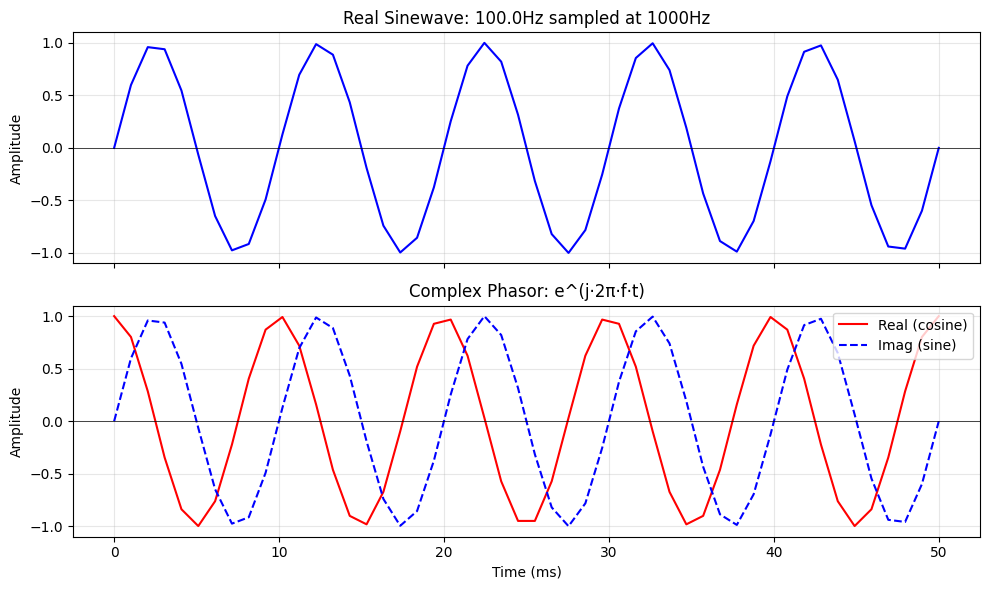

The phasor encodes both cosine (real) and sine (imaginary) in one complex tensor.


In [19]:
# Plot the sinewave and the complex phasor components
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Top: real sinewave
axes[0].plot(t.numpy() * 1000, sinewave.numpy(), 'b-', linewidth=1.5)
axes[0].set_ylabel('Amplitude')
axes[0].set_title(f'Real Sinewave: {freq}Hz sampled at {sample_rate}Hz')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='k', linewidth=0.5)

# Bottom: complex phasor (real and imaginary)
axes[1].plot(t.numpy() * 1000, phasor.real.numpy(), 'r-', linewidth=1.5, label='Real (cosine)')
axes[1].plot(t.numpy() * 1000, phasor.imag.numpy(), 'b--', linewidth=1.5, label='Imag (sine)')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Amplitude')
axes[1].set_title('Complex Phasor: e^(j·2π·f·t)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()
print("The phasor encodes both cosine (real) and sine (imaginary) in one complex tensor.")